# CLT and LLN

Law of Large Numbers (LLN): sample mean converge to the population mean as the sample size grows</br>
Central Limit Theorem (CLT): sampling distribution of the sample mean approaches a normal distribution

Text(0.5, 1.0, 'Law of Large Numbers')

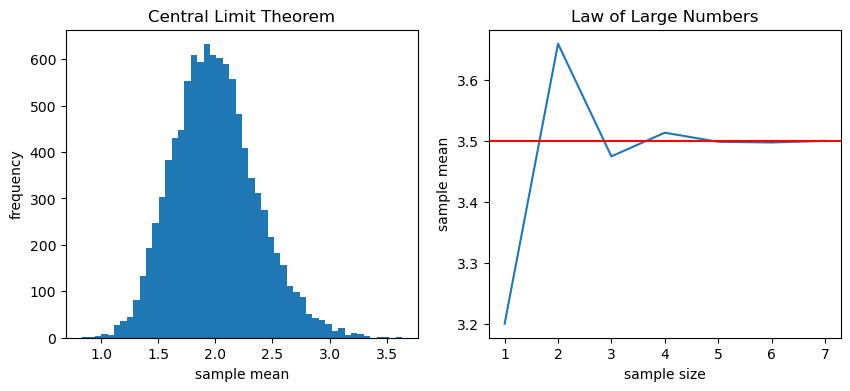

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# central limit theorem
x = np.random.exponential(scale=2, size=10000*30).reshape(10000, 30)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plo = ax1.hist(x.mean(axis=1),bins=50)
ax1.set_xlabel("sample mean")
ax1.set_ylabel("frequency")
ax1.set_title("Central Limit Theorem")

# Law of large numebrs
y = {} 
avg = {}
for x in range(1,8):
    n = 10**x
    y[x] = np.random.randint(1,7,n)
    avg[x] = y[x].mean()
ax2.plot(list(avg.keys()),list(avg.values()))
ax2.axhline(y=3.5,color="r")
ax2.set_xlabel("sample size")
ax2.set_ylabel("sample mean")
ax2.set_title("Law of Large Numbers")

# Stock Return gain CLT

Why are stock returns often modeled as normally distributed even though they aren’t perfectly normal?

In [ ]:
import yfinance as yf
import pandas as pd
spy_data = yf.download('SPY', period='5y')


spy_data.columns = spy_data.columns.get_level_values(0)
spy_data = spy_data.sort_index()
spy_data['Daily_Gain'] = spy_data["Close"].pct_change()

C:\Users\mamma\AppData\Local\Temp\ipykernel_26652\1369834754.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy_data = yf.download('SPY', period='5y')
[*********************100%***********************]  1 of 1 completed


Normal Data - Statistic: 0.997, p-value: 0.092
Data likely come from a normal distribution (fail to reject H0)


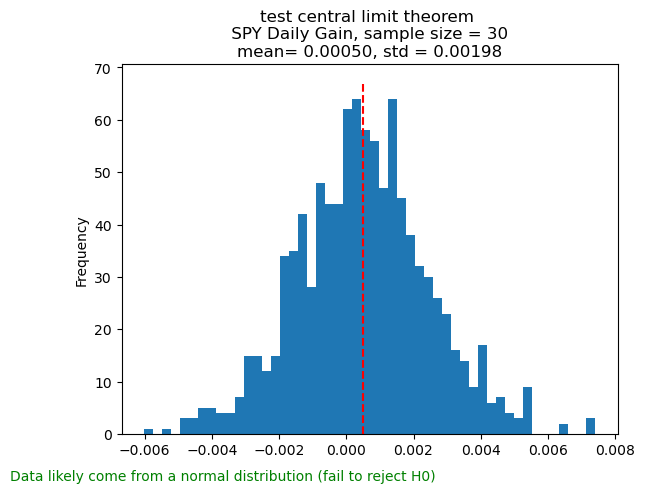

In [155]:
sample_size = 30
num_experiments = 1000  # Number of random samples to take
sample_means = {}
for i in range(num_experiments):
    sample = spy_data['Daily_Gain'].sample(n=sample_size, random_state=i)
    sample_means[i] = sample.mean()
df = pd.Series(sample_means)
ax = df.plot.hist(bins=50)
plt.title(f"test central limit theorem \n SPY Daily Gain, sample size = {sample_size} \nmean= {df.mean():.5f}, std = {df.std():.5f}")
ymin, ymax = ax.get_ylim()
plt.vlines(df.mean(),ymin,ymax, color="r",linestyles='dashed')
from scipy.stats import shapiro
alpha = 0.05
# hypothesis (H0) is that the data is normally distributed. 
stat_normal, p_normal = shapiro(df)
print(f"Normal Data - Statistic: {stat_normal:.3f}, p-value: {p_normal:.3f}")
if p_normal > alpha:
    c = "g"
    text_to_show = "Data likely come from a normal distribution (fail to reject H0)"
    print(text_to_show)
else:
    c="r"
    text_to_show = "Data likely do not come from a normal distribution (reject H0).\n"
    print(text_to_show)
tt = ax.text(-.01,-8, text_to_show, color=c,ha='left',va='center')

# Hypothesis Testing

State the null and alternative hypotheses when testing if a coin is fair. $P(X=x) = C(n, x) * p^x * (1 - p)^{n-x}$

$$Z={\frac {{\hat {p}}-p_{0}}{\sqrt {\frac {p_{0}(1-p_{0})}{n}}}}$$


## A fair coin

In [76]:
from scipy.stats import binomtest
alpha = 0.05
x = np.random.binomial(n=100, p=0.5)
# Perform a two-sided binomial test
p_val = binomtest(x, n=100, p=0.5)
alpha = 0.05
if p_val.pvalue < alpha:
    print("Reject the null hypothesis: The coin is likely not fair.")
else:
    print("Fail to reject the null hypothesis: There is no significant evidence to suggest the coin is not fair.")

Fail to reject the null hypothesis: There is no significant evidence to suggest the coin is not fair.


## A skew coin

In [ ]:
alpha = 0.05
x = np.random.binomial(n=100, p=0.5)
# Perform a two-sided binomial test
p_val = binomtest(x, n=100, p=0.6)
alpha = 0.05
if p_val.pvalue < alpha:
    print("Reject the null hypothesis: The coin is likely not fair.")
else:
    print("Fail to reject the null hypothesis: There is no significant evidence to suggest the coin is not fair.")

# interestingly if we repeat the test for some of them we fail to reject H0

Reject the null hypothesis: The coin is likely not fair.


# Margin of Error (confidence Interval)

Difference between the sample value and true population value
$$ME = {z * {\frac {S}{\sqrt {n}}}}$$


A 95% confidence interval provides a range of plausible values for an unknown population parameter, with the confidence reflecting the reliability of the method used to generate the interval. If you were to take many random samples and calculate a 95% confidence interval for each, 95% of those intervals would contain the true population value. 

# Bayesian Updating

Contrast frequentist and Bayesian interpretations of probability

# Chi-Square Goodness of Fit

measures 

- Deviation from Expectation: The core purpose is to quantify how much your observed data deviates from what you would expect if the null hypothesis were true. 
- Association Between Categorical Variables: It assesses if there's a relationship between two or more nominal (or categorical) variables, such as "gender" and "marital status". 
- Goodness of Fit: It evaluates how well your observed data fits a theoretical or expected distribution, like testing if a coin is fair (i.e., has an even chance of landing heads or tails). 


The chi-square statistic ($\chi^2$) is calculated using the formula where O is observed and E is expected value:

$$ \chi^2 = \sum \frac{(O_i - E_i)^2}{E_i} $$

## Fair die
Roll a die 600 times. 
Test whether the die is fair using a chi-square test.



Interpretation:
The p-value (0.5016) is greater than the significance level (0.05).
We fail to reject the null hypothesis. There is not enough evidence to conclude the die is unfair.


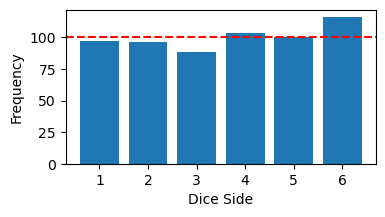

In [194]:
from scipy.stats import chisquare
die_rolls = np.random.randint(1,7, 600)
expected_frequency_per_side = 600 / 6
observed_frequencies = np.bincount(die_rolls)[1:]
expected_frequencies = np.full(6,expected_frequency_per_side)
chi2_stat, p_value = chisquare(f_obs=observed_frequencies, f_exp=expected_frequencies)


print("\nInterpretation:")
if p_value < alpha:
    print(f"The p-value ({p_value:.4f}) is less than the significance level ({alpha}).")
    print("We reject the null hypothesis. The die is likely not fair.")
else:
    print(f"The p-value ({p_value:.4f}) is greater than the significance level ({alpha}).")
    print("We fail to reject the null hypothesis. There is not enough evidence to conclude the die is unfair.")

plt.figure(figsize=(4,2))
plt.bar(list(np.arange(1,7)),observed_frequencies)
plt.ylabel("Frequency")
plt.xlabel("Dice Side")
plt.axhline(expected_frequency_per_side, color='red', linestyle='--')


Try again with a loaded die (p=[0.1,0.1,0.1,0.1,0.1,0.5]).


Interpretation:
The p-value (0.0000) is less than the significance level (0.05).
We reject the null hypothesis. The die is likely not fair.


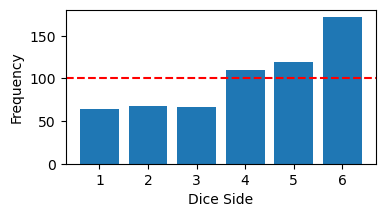

In [197]:
probabilities = [0.1, 0.1, 0.1, 0.2, 0.2, 0.3]
sides = np.arange(1, 7) # Corresponds to die faces 1 through 6

# Use np.random.choice to simulate rolls with the specified probabilities
rolls = np.random.choice(sides, size=600, p=probabilities)
observed_frequencies = np.bincount(rolls, minlength=7)[1:]
chi2_stat, p_value = chisquare(f_obs=observed_frequencies, f_exp=expected_frequencies)

print("\nInterpretation:")
if p_value < alpha:
    print(f"The p-value ({p_value:.4f}) is less than the significance level ({alpha}).")
    print("We reject the null hypothesis. The die is likely not fair.")
else:
    print(f"The p-value ({p_value:.4f}) is greater than the significance level ({alpha}).")
    print("We fail to reject the null hypothesis. There is not enough evidence to conclude the die is unfair.")


plt.figure(figsize=(4,2))
plt.bar(list(np.arange(1,7)),observed_frequencies)
plt.ylabel("Frequency")
plt.xlabel("Dice Side")
plt.axhline(expected_frequency_per_side, color='red', linestyle='--')